In [ ]:
import pandas as pd
import zipfile
import os

# my da file is in zip : Unzip the file

zip_path = 'archive.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('nano_data')

# Find the CSV file inside the extracted folder

csv_file = 'nano_data/carbon_nanotubes.csv'

# Load the data

df = pd.read_csv(csv_file, sep=';', decimal=',')

print("Dataset loaded successfully!")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
df.head()

Dataset loaded successfully!
Total Rows: 10721 | Total Columns: 1


,"Chiral indice n,Chiral indice m,Initial atomic coordinate u,Initial atomic coordinate v,Initial atomic coordinate w,Calculated atomic coordinates u',Calculated atomic coordinates v',Calculated atomic coordinates w'"
0,"2,1,""0,679005"",""0,701318"",""0,017033"",""0,721039..."
1,"2,1,""0,717298"",""0,642129"",""0,231319"",""0,738414..."
2,"2,1,""0,489336"",""0,303751"",""0,088462"",""0,477676..."
3,"2,1,""0,413957"",""0,632996"",""0,040843"",""0,408823..."
4,"2,1,""0,334292"",""0,543401"",""0,15989"",""0,303349""..."


In [ ]:
df = pd.read_csv(csv_file, sep=',', decimal=',')
print(f"New Column Count: {df.shape[1]}")
print(df.columns.tolist())

New Column Count: 8
['Chiral indice n', 'Chiral indice m', 'Initial atomic coordinate u', 'Initial atomic coordinate v', 'Initial atomic coordinate w', "Calculated atomic coordinates u'", "Calculated atomic coordinates v'", "Calculated atomic coordinates w'"]


PREPROSESSING OF DATA: CLEANED THE DATA.
NEXT STEP IS TO SPLIT THE DATA TO TRAIN THE AI. THAT IS AI TRAINING

In [ ]:
from sklearn.model_selection import train_test_split

# Define Inputs (X) and Targets (y)
X = df[['Chiral indice n', 'Chiral indice m', 'Initial atomic coordinate u',
        'Initial atomic coordinate v', 'Initial atomic coordinate w']]

# predicting the three calculated coordinates
y = df[['Calculated atomic coordinates u\'', 'Calculated atomic coordinates v\'',
        'Calculated atomic coordinates w\'']]

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 8576 rows
Testing set size: 2145 rows


AFTER SPLITTING THE DATA:
Training set size: 8576 rows
Testing set size: 2145 rows

NEXT STEP IS TO TRAIN THE DATA : RANDOM FOREST REGRESSION...THE CODE TO TRAIN THE MODEL IS....

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Initializing the Model

model = RandomForestRegressor(n_estimators=100, random_state=42)     # n_estimators=100 means i am using 100 mini-trees to vote on the result

print("Training the AI")
model.fit(X_train, y_train)

# Testing the Model
predictions = model.predict(X_test)
error = mean_absolute_error(y_test, predictions)

print(f"Project Complete! Average Prediction Error: {error:.6f}")

Training the AI
Project Complete! Average Prediction Error: 0.007078


Visualizing AI Performance

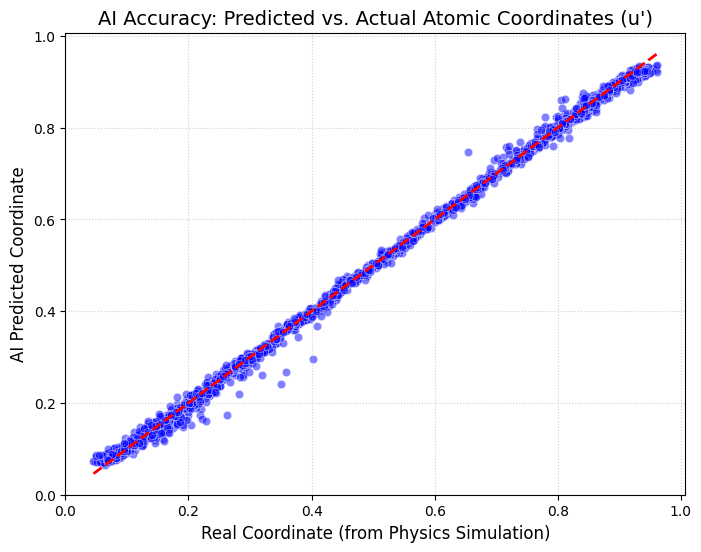

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a plot for the first coordinate (u)
plt.figure(figsize=(8, 6))

# Plotting the test values against the AI's predictions
sns.scatterplot(x=y_test.iloc[:, 0], y=predictions[:, 0], alpha=0.5, color='blue')

max_val = max(y_test.iloc[:, 0].max(), predictions[:, 0].max())
min_val = min(y_test.iloc[:, 0].min(), predictions[:, 0].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--')

plt.title('AI Accuracy: Predicted vs. Actual Atomic Coordinates (u\')', fontsize=14)
plt.xlabel('Real Coordinate (from Physics Simulation)', fontsize=12)
plt.ylabel('AI Predicted Coordinate', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()